The project was updated from a binary classification task to a multiclass classification task based on insights from the data.

In [ ]:
#imports 
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
#load data
url = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"

df = pd.read_csv(url)

df.head()

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [3]:
#creating target variable
def label_quality(score):
    if score < 82:
        return 0  # low
    elif score < 86:
        return 1  # medium
    else:
        return 2  # high

df['quality_label'] = df['Total.Cup.Points'].apply(label_quality)

In [4]:
#keeping only numeric features 
features = [
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Balance',
    'Acidity',
    'Moisture',
    'Quakers'
]

X = df[features]
y = df['quality_label']

In [5]:
#train / validation /test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [6]:
#scale features 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
#classical baseline (logistic regression)
import numpy as np

X_train = np.nan_to_num(X_train, nan=np.nanmean(X_train, axis=0))
X_val = np.nan_to_num(X_val, nan=np.nanmean(X_train, axis=0))
X_test = np.nan_to_num(X_test, nan=np.nanmean(X_train, axis=0))

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("LR F1:", f1_score(y_test, y_pred_lr, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

LR Accuracy: 0.883248730964467
LR F1: 0.7796688618038018
Confusion Matrix:
 [[ 63   9   0]
 [ 11 109   0]
 [  0   3   2]]


In [8]:
#deep learning baseline (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("MLP F1:", f1_score(y_test, y_pred_mlp, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))

MLP Accuracy: 0.883248730964467
MLP F1: 0.8365789097152669
Confusion Matrix:
 [[ 62  10   0]
 [ 11 109   0]
 [  0   2   3]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


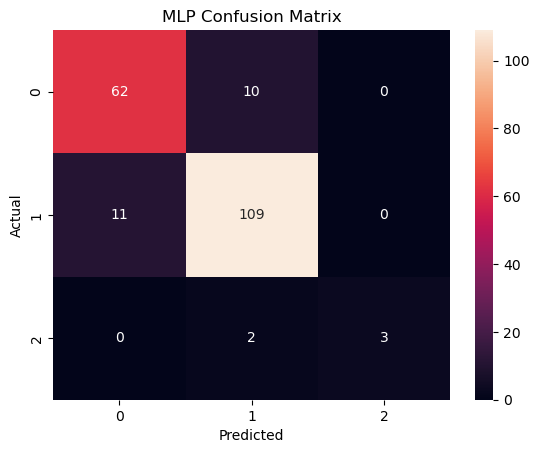

In [9]:
#visualization
cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison
Both logistic regression and the neural network achieve strong but not perfect performance on this task. The neural network slightly outperforms logistic regression in terms of F1 score, suggesting it is better at handling class imbalance and capturing more complex relationships. However, the overall performance of both models is similar, indicating that much of the signal in the data can still be captured by simpler linear models. 

## Failure Analysis
While overall accuracy is high, the models struggle to correctly classify the highest quality class. This is primarily due to class imbalance, as there are significantly fewer examples of high-quality coffees in the dataset. Most misclassifications occur between neighboring classes (e.g., medium vs. high), indicating that distinguishing fine-grained differences in quality remains challenging even with meaningful features. 